## Lake Zug Glider Collaboration (2026.04.14)

In [33]:
# imports
import ewgreaders as ewg
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm

### Lake Zug

In [2]:
bathy = xr.open_dataset('Q:/Messdaten/Aphys_Hypothesis_data/Zug/bathymetry.nc')

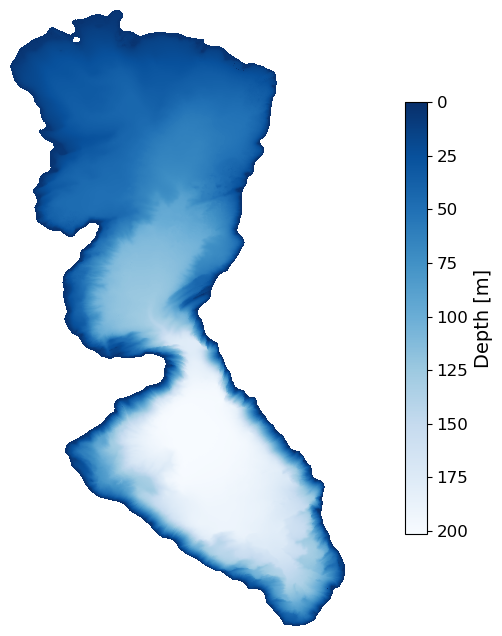

In [6]:
fig, ax = plt.subplots(figsize=(6, 8))

im = ax.pcolormesh(bathy['xsc'], bathy['ysc'], bathy['depth'], cmap='Blues_r', vmin=0, rasterized=True)
cbar = fig.colorbar(im, shrink=0.7, location='right', pad=0.13, ax=ax)
cbar.ax.invert_yaxis()

cbar.ax.tick_params(labelsize=12)
cbar.set_label('Depth [m]', size=14)

ax.set_xticks([])
ax.set_yticks([])
ax.spines[['right', 'top', 'left', 'bottom']].set_visible(False)

plt.savefig('../gallery/collab/2026_04_14/zug_map.png', bbox_inches='tight')
plt.show()

### Anoxic depth in S basin

In [13]:
def transect_min_do(di_sel):
    min_do = []
    for _, p in di_sel.iterrows():
        ctdreader = ewg.ctd_reader.CTDReader(p.lake, p.date, p.fname)
        try:
            ds = ctdreader.load()
            min_do.append(ds['do2_conc'].min().item())
        except FileNotFoundError:
            continue

    return min(min_do)

In [35]:
di = ewg.get_data_index('Zug', 'ctd').query("date > '2025-09-15'")
di

,lake,date,time,profile_loc,xsc,ysc,sensor,serial_id,fname
141,Zug,2025-10-29,09:57,LZ3,680026,217233,sea&sun,1807,JA290917_1
142,Zug,2025-11-07,10:08,P1,679728,223925,sea&sun,1807,JB071625_1
143,Zug,2025-11-07,10:19,P2,679761,222747,sea&sun,1807,JB071625_2
144,Zug,2025-11-07,10:31,P3,679678,221735,sea&sun,1807,JB071625_3
145,Zug,2025-11-07,10:45,P4,679443,220409,sea&sun,1807,JB071625_4
...,...,...,...,...,...,...,...,...,...
338,Zug,2026-04-09,14:19,P6E,680267,218863,sea&sun,2023,K4101445_4
339,Zug,2026-04-09,14:31,P6W,679931,218791,sea&sun,2023,K4101445_6
340,Zug,2026-04-09,14:54,P10,680813,216240,sea&sun,2023,K4101445_7
341,Zug,2026-04-10,10:19,P6E,680288,218845,sea&sun,2023,K4101445_8


In [36]:
min_do_map = {}
for d, di_sel in tqdm(di.groupby('date')):
    min_do = transect_min_do(di_sel)
    min_do_map[d] = min_do

  0%|          | 0/26 [00:00<?, ?it/s]

In [40]:
s_basin = ["P9", "P9'", "VMPS", "P10", "P10'", "PS", "LZ3"]
constriction_center = ["P6", "VMPC", "PC", "P7"]
constriction_boundary = ["P6W", "P6E", "P6E'", "VMPW", "P7W"]

In [168]:
data = []
for _, p in tqdm(di.iterrows()):
    if p.profile_loc in s_basin + constriction_center + constriction_boundary:
        ctdreader = ewg.ctd_reader.CTDReader(p.lake, p.date, p.fname)
        min_do = min_do_map[p.date]
        basin = 'S' if p.profile_loc in s_basin else 'C'
        region = 'S' if p.profile_loc in s_basin else 'C' if p.profile_loc in constriction_center else 'B'

        try:
            ds = ctdreader.load()
            mask = ds['do2_conc'] <= min_do + 0.2
            if mask.sum() > 0:
                anoxic_depth = ds.where(mask, drop=True).depth.min().item()
            else:
                anoxic_depth = np.nan
            
            data.append({
                    'date': p.date,
                    'time': p.time,
                    'basin': basin,
                    'region': region,
                    'profile_loc': p.profile_loc,
                    'xsc': p.xsc,
                    'ysc': p.ysc,
                    'sensor': p.sensor,
                    'serial_id': p.serial_id,
                    'profile_depth': ds.depth.max().item(),
                    'anoxic_depth': anoxic_depth,
                })
        except FileNotFoundError:
            continue

data = pd.DataFrame(data)

0it [00:00, ?it/s]

C:\Users\herremha\AppData\Local\Temp\ipykernel_2968\3908161464.py:6: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  sns.scatterplot(data.query("date == '2026-02-13' and basin == 'S'"), x='date', y='anoxic_depth', marker='X', s=100, color='gray', zorder=2, ax=ax)


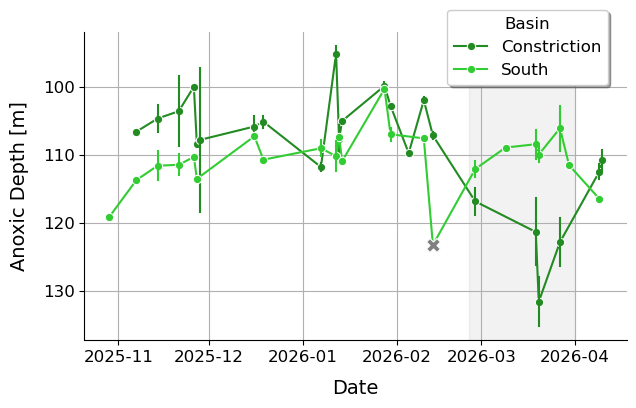

In [186]:
fig, ax = plt.subplots(figsize=(7, 4))
palette = ['forestgreen', 'limegreen']

sns.lineplot(data, x='date', y='anoxic_depth', hue='basin', hue_order=['C', 'S'], palette=palette,
             marker='o',errorbar=('se', 1), err_style='bars', ax=ax)
sns.scatterplot(data.query("date == '2026-02-13' and basin == 'S'"), x='date', y='anoxic_depth', marker='X', s=100, color='gray', zorder=2, ax=ax)
ax.axvspan('2026-02-25', '2026-04-01', color='gray', alpha=0.1)

ax.set_xlabel('Date', fontsize=14, labelpad=10)
ax.set_ylabel('Anoxic Depth [m]', fontsize=14, labelpad=10)
ax.tick_params(axis='both', labelsize=12)

ax.invert_yaxis()
ax.spines[['right', 'top']].set_visible(False)
ax.grid(True)
labels = ['Constriction', 'South']
handles, _ = ax.get_legend_handles_labels()
ax.legend(handles, labels, title='Basin', ncols=1, fontsize=12, title_fontsize=12, shadow=True, loc='upper right', bbox_to_anchor=(0.98, 1.1))

plt.savefig('../gallery/collab/2026_04_14/anoxia.png', bbox_inches='tight')
plt.show()

### Oxygen to bottom along constriction sides

2026.03.20

In [187]:
di_sel = di.query("date == '2026-03-20'")

min_do = transect_min_do(di_sel)

C:\Users\herremha\AppData\Local\Temp\ipykernel_2968\1846323386.py:1: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  di_sel = di.query("date == '2026-03-20'")


In [188]:
data = []
for _, p in tqdm(di_sel.iterrows()):
    if p.profile_loc in constriction_center + constriction_boundary:
        ctdreader = ewg.ctd_reader.CTDReader(p.lake, p.date, p.fname)

        try:
            ds = ctdreader.load()
            df = (ds['do2_conc'] - min_do).to_dataframe().reset_index()
            df[['time', 'profile_loc']] = p.time, p.profile_loc
            data.append(df)

        except FileNotFoundError:
            continue

data = pd.concat(data, ignore_index=True)

0it [00:00, ?it/s]

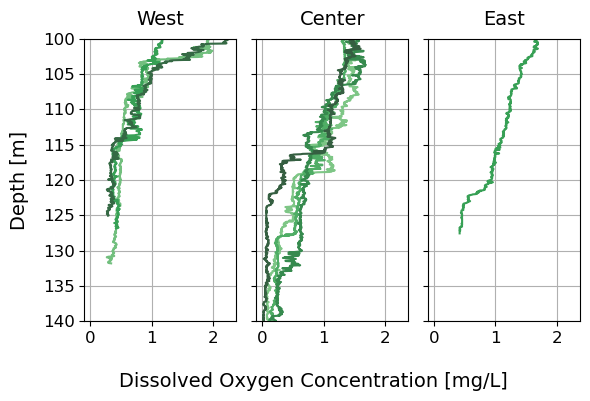

In [189]:
ymin = 100
ymax = 140
data_sel = data.query("depth > @ymin and depth < @ymax")

fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(6, 4), sharey=True, sharex=True)

sns.lineplot(data_sel[data_sel['profile_loc'] == 'P6W'], x='do2_conc', y='depth', orient='y', hue='time', palette='Greens_d', ax=ax[0], legend=False)
sns.lineplot(data_sel[data_sel['profile_loc'].isin(['P6', 'P7'])], x='do2_conc', y='depth', orient='y', hue='time', palette='Greens_d', ax=ax[1], legend=False)
sns.lineplot(data_sel[data_sel['profile_loc'] == 'P6E'], x='do2_conc', y='depth', orient='y', hue='time', palette='Greens_d', ax=ax[2], legend=False)

ax[0].set_ylabel('Depth [m]', fontsize=14, labelpad=10)
ax[0].set_title('West', fontsize=14, pad=10)
ax[1].set_title('Center', fontsize=14, pad=10)
ax[2].set_title('East', fontsize=14, pad=10)


for i in range(len(ax)):
    ax[i].set_xlabel('')
    ax[i].set_ylim(ymin, ymax)
    ax[i].tick_params(axis='both', labelsize=12)
    ax[i].grid(True)

ax[0].invert_yaxis()
fig.supxlabel('Dissolved Oxygen Concentration [mg/L]', fontsize=14, x=0.53)

plt.tight_layout()
plt.savefig('../gallery/collab/2026_04_14/full_oxygen.png', bbox_inches='tight')
plt.show()

### South basin lateral intrusion

2026.02.13 at VMPS

In [93]:
di_p = di.query("date == '2026-02-13' and profile_loc == 'VMPS'")
di_p

C:\Users\herremha\AppData\Local\Temp\ipykernel_2968\1350509086.py:1: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  di_p = di.query("date == '2026-02-13' and profile_loc == 'VMPS'")


,lake,date,time,profile_loc,xsc,ysc,sensor,serial_id,fname
278,Zug,2026-02-13,15:01,VMPS,680436,216858,sea&sun,1807,K2131606_8


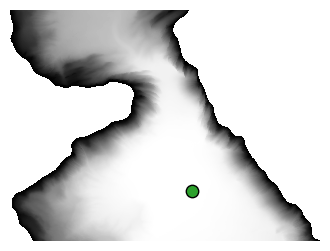

In [89]:
bathy_sel = bathy.sel(xsc=slice(2677800, 2682300), ysc=slice(1216000, 1220000))

fig, ax = plt.subplots(figsize=(4, 3))

im = ax.pcolormesh(bathy_sel['xsc'], bathy_sel['ysc'], bathy_sel['depth'], cmap='Greys_r', vmin=0, rasterized=True)

ax.scatter(2680436, 1216858, s=80, c='tab:green', edgecolor='black')

ax.set_xticks([])
ax.set_yticks([])
ax.spines[['right', 'top', 'left', 'bottom']].set_visible(False)

plt.savefig('../gallery/collab/2026_04_14/sbasin_intrusion_map.png', bbox_inches='tight')
plt.show()

### Workspace

In [61]:
data = []
for _, p in tqdm(di_sel.iterrows()):
    ctdreader = ewg.ctd_reader.CTDReader(p.lake, p.date, p.fname)
    try:
        ds = ctdreader.load()
        min_do = ds['do2_conc'].min().item()
        anoxic_err = ds.where(ds['do2_conc'] <= min_do + 0.2, drop=True).depth.min().item()
        anoxic_depth = ds.where(ds['do2_conc'] <= min_do + 0.01, drop=True).depth.min().item()
        o2_depth = ds.where(ds['do2_conc'] > min_do + 0.01, drop=True).depth.max().item()
        o2_err = ds.where(ds['do2_conc'] > min_do + 0.2, drop=True).depth.max().item()
        data.append({
                'date': p.date,
                'time': p.time,
                'basin': 'S',
                'profile_loc': p.profile_loc,
                'xsc': p.xsc,
                'ysc': p.ysc,
                'sensor': p.sensor,
                'serial_id': p.serial_id,
                'profile_depth': ds.depth.max().item(),
                'anoxic_err': anoxic_err,
                'anoxic_depth': anoxic_depth,
                'o2_depth': o2_depth,
                'o2_err': o2_err
            })
    except FileNotFoundError:
        continue

data = pd.DataFrame(data)

0it [00:00, ?it/s]

In [62]:
dfm = pd.melt(data.query("profile_depth > 130"), id_vars=['date', 'profile_loc'], value_vars=['anoxic_err', 'anoxic_depth', 'o2_depth', 'o2_err'],
              var_name='label', value_name='depth')

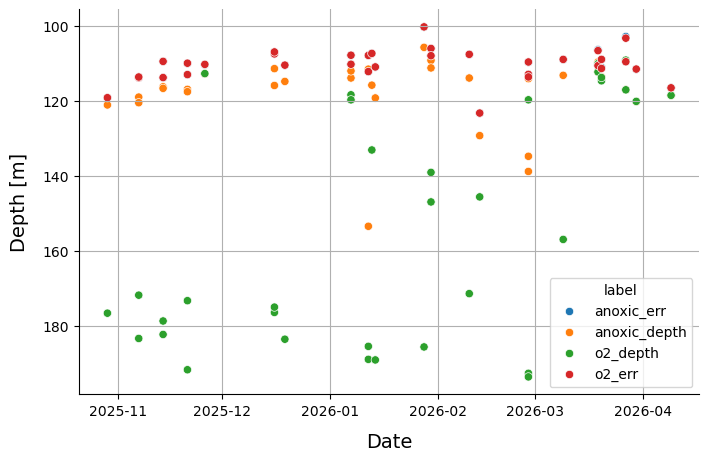

In [63]:
fig, ax = plt.subplots(figsize=(8, 5))

sns.scatterplot(dfm, x='date', y='depth', hue='label', ax=ax)

ax.set_xlabel('Date', fontsize=14, labelpad=10)
ax.set_ylabel('Depth [m]', fontsize=14, labelpad=10)

ax.invert_yaxis()
ax.spines[['right', 'top']].set_visible(False)
ax.grid(True)

plt.show()

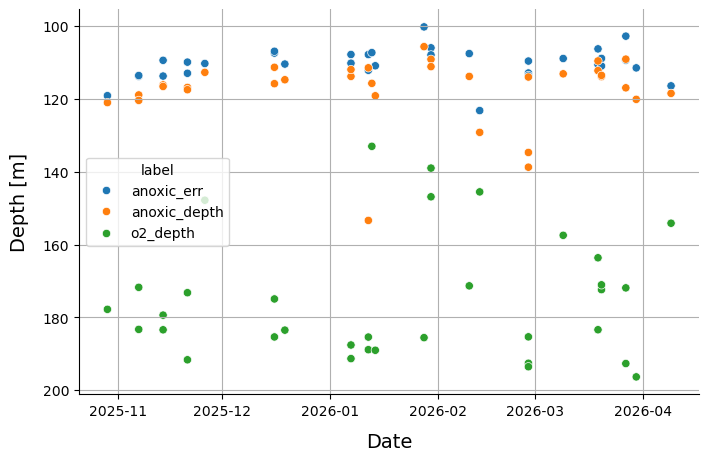

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))

sns.scatterplot(dfm, x='date', y='depth', hue='label', ax=ax)

ax.set_xlabel('Date', fontsize=14, labelpad=10)
ax.set_ylabel('Depth [m]', fontsize=14, labelpad=10)

ax.invert_yaxis()
ax.spines[['right', 'top']].set_visible(False)
ax.grid(True)

plt.show()

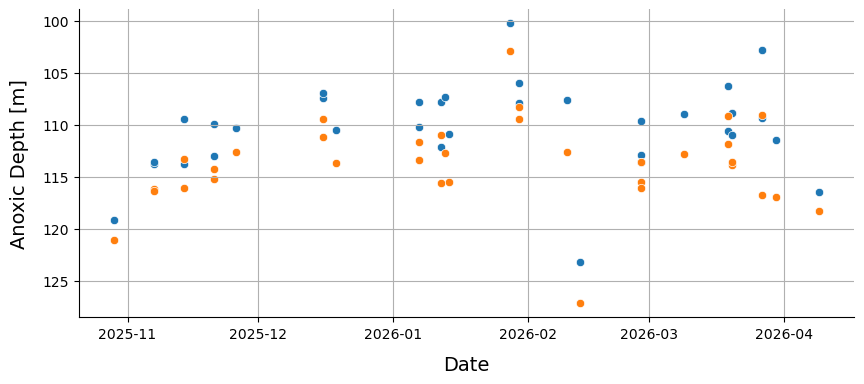

In [ ]:
fig, ax = plt.subplots(figsize=(10, 4))

sns.scatterplot(data.query("profile_depth > 130"), x='date', y='anoxic_err', ax=ax)
sns.scatterplot(data.query("profile_depth > 130"), x='date', y='anoxic_depth', ax=ax)

ax.set_xlabel('Date', fontsize=14, labelpad=10)
ax.set_ylabel('Anoxic Depth [m]', fontsize=14, labelpad=10)

ax.invert_yaxis()
ax.spines[['right', 'top']].set_visible(False)
ax.grid(True)

plt.show()

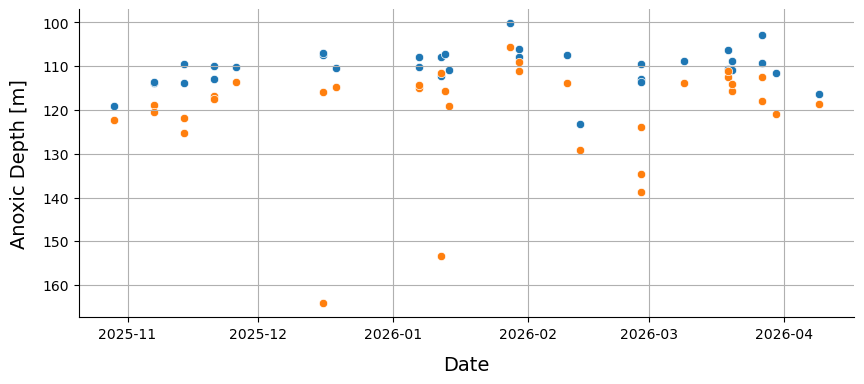

In [45]:
fig, ax = plt.subplots(figsize=(10, 4))

sns.scatterplot(data.query("profile_depth > 130"), x='date', y='anoxic_err', ax=ax)
sns.scatterplot(data.query("profile_depth > 130"), x='date', y='anoxic_depth', ax=ax)

ax.set_xlabel('Date', fontsize=14, labelpad=10)
ax.set_ylabel('Anoxic Depth [m]', fontsize=14, labelpad=10)

ax.invert_yaxis()
ax.spines[['right', 'top']].set_visible(False)
ax.grid(True)

plt.show()

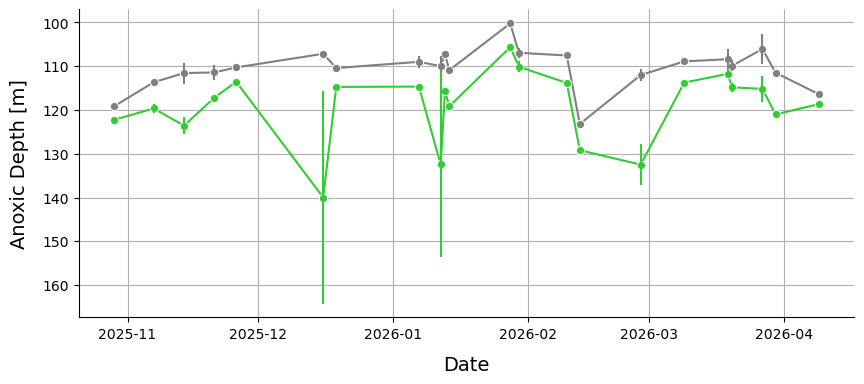

In [44]:
fig, ax = plt.subplots(figsize=(10, 4))

sns.lineplot(data.query("profile_depth > 130"), x='date', y='anoxic_err', color='gray', marker='o',errorbar=('se', 1), err_style='bars', ax=ax)
sns.lineplot(data.query("profile_depth > 130"), x='date', y='anoxic_depth', color='limegreen', marker='o',errorbar=('se', 1), err_style='bars', ax=ax)

ax.set_xlabel('Date', fontsize=14, labelpad=10)
ax.set_ylabel('Anoxic Depth [m]', fontsize=14, labelpad=10)

ax.invert_yaxis()
ax.spines[['right', 'top']].set_visible(False)
ax.grid(True)

plt.show()

In [22]:
data

,date,time,basin,profile_loc,xsc,ysc,sensor,serial_id,anoxic_depth
0,2024-11-08,10:21,S,P10',680236,216423,sea&sun,1807,139.543709
1,2024-11-08,10:42,S,P9,680173,217479,sea&sun,1807,132.582688
2,2025-01-15,11:16,S,P10',680425,216334,sea&sun,1807,154.315656
3,2025-02-14,12:30,S,P9,680409,217437,sea&sun,2023,127.075896
4,2025-02-14,12:31,S,P9,680409,217437,sea&sun,1807,128.074852
5,2025-02-14,12:50,S,P10,680814,216239,sea&sun,1807,128.758556
6,2025-02-14,12:50,S,P10,680814,216239,sea&sun,2023,129.113416
7,2025-04-02,11:11,S,P9,680409,217437,sea&sun,1807,131.571318
8,2025-04-02,11:31,S,P10,680814,216239,sea&sun,1807,126.031208
9,2025-04-02,15:13,S,P9,680409,217437,sea&sun,1807,128.567326


In [14]:
min_do

0.14

In [18]:
ds.where(ds['do2_conc'] <= min_do, drop=True).depth.min().item()

118.64750863001848

In [ ]:
data = []
for _, p in tqdm(di.iterrows()):
    ctdreader = ewg.ctd_reader.CTDReader(p.lake, p.date, p.fname)
    if p.profile_loc in s_basin:
        try:
            ds = ctdreader.load()
            if ds.depth.max() > 115:
                data.append({
                    'date': p.date,
                    'time': p.time,
                    'basin': 'S',
                    'profile_loc': p.profile_loc,
                    'xsc': p.xsc,
                    'ysc': p.ysc,
                    'sensor': p.sensor,
                    'serial_id': p.serial_id,
                    'temp': ds['temp'].sel(depth=115, method='nearest').item(),
                    'do2': ds['do2_conc'].sel(depth=115, method='nearest').item()
                })
        except FileNotFoundError:
            continue

data = pd.DataFrame(data)